# 02 — Modelagem Supervisionada: Predição de Alfabetização Municipal

**Tech Challenge Fase 3** — Predição e Inteligência Analítica para Alfabetização no Brasil

## Objetivo analítico

Prever se um município (rede municipal) **atingirá adequadamente seu padrão de alfabetização**,
operacionalizado como `alvo_alfabetizado = 1` quando a taxa de alfabetização observada é maior
ou igual à meta municipal 2025 do Compromisso Nacional Criança Alfabetizada (PNA), e `0` caso
contrário — proxy municipal para "aluno alfabetizado", já que o INEP não publica microdados por
aluno (sigilo estatístico/LGPD). Essa decisão está detalhada no notebook `01_analise_exploratoria.ipynb`
e em `src/preprocessing/build_features.py`.

## Estratégia de validação (anti data-leakage)

- **Split temporal**: treino = ano 2023 (5.302 municípios), *holdout* = ano 2024 (5.352 municípios).
  O modelo nunca vê 2024 durante o tuning — testa generalização real para o futuro.
- **Tuning**: `GridSearchCV` com `StratifiedKFold` (5 folds) **dentro do treino (2023)**.
- **Pipeline integrada**: imputação + encoding + escala estão dentro do `sklearn.Pipeline`,
  reajustados a cada fold — nenhuma estatística do fold de validação ou do holdout vaza para o treino.
- **Features excluídas por leakage**: `taxa_alfabetizacao`, `gap_meta_2025`, `nivel_alfabetizacao`,
  `proporcao_aluno_nivel_5..8` (ver notebook 01 para a análise de correlação que fundamenta a exclusão).


In [1]:
import sys
sys.path.insert(0, "..")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, StratifiedKFold

from src.etl.paths import DATA_DIR, ROOT
from src.modeling.pipeline import (
    CATEGORICAL_FEATURES, NUMERIC_FEATURES, PARAM_GRIDS, TARGET, build_model_pipelines,
)
from src.evaluation.metrics import compute_metrics, confusion
from src.evaluation.interpretability import native_feature_importance, shap_summary
from src.visualization.plots import plot_confusion_matrix, plot_feature_importance, plot_roc_curve

sns.set_theme(style="whitegrid")
FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
print("Features numéricas:", NUMERIC_FEATURES)
print("Features categóricas:", CATEGORICAL_FEATURES)


Features numéricas: ['media_portugues', 'meta_2025', 'meta_uf_2025', 'taxa_media_uf_loo']
Features categóricas: ['sigla_uf', 'regiao']


## 1. Dataset de modelagem e split temporal

In [2]:
df = pd.read_parquet(DATA_DIR / "features" / "dataset_modelagem.parquet")
print(df.shape)
display(df.head())

treino = df[df["ano"] == 2023]
teste = df[df["ano"] == 2024]

X_train, y_train = treino[FEATURES], treino[TARGET]
X_test, y_test = teste[FEATURES], teste[TARGET]

print(f"\nTreino (2023): {len(X_train)} municípios | positivos: {y_train.mean():.1%}")
print(f"Holdout (2024): {len(X_test)} municípios | positivos: {y_test.mean():.1%}")


(10654, 9)


,id_municipio,ano,sigla_uf,regiao,media_portugues,meta_2025,meta_uf_2025,taxa_media_uf_loo,alvo_alfabetizado
0,1100031,2023,RO,Norte,767.88,72.53,69.5,65.00,0
1,1100072,2023,RO,Norte,747.89,65.31,69.5,65.21,0
2,1101609,2023,RO,Norte,745.68,60.25,69.5,65.36,0
3,1101807,2023,RO,Norte,752.37,63.63,69.5,65.26,0
4,1302900,2023,AM,Norte,731.07,61.93,61.3,46.13,0



Treino (2023): 5302 municípios | positivos: 18.1%
Holdout (2024): 5352 municípios | positivos: 43.4%


## 2. Pipeline de pré-processamento + modelos candidatos

Três modelos são comparados, todos com pré-processamento integrado ao `Pipeline` do Scikit-learn:

- **Regressão Logística** (baseline interpretável, `class_weight="balanced"`)
- **Random Forest** (captura não-linearidades e interações)
- **Gradient Boosting** (boosting sequencial, regularizado por profundidade rasa)

O pré-processamento aplica:
- `SimpleImputer(strategy="median")` + `StandardScaler` nas variáveis numéricas;
- `SimpleImputer(strategy="most_frequent")` + `OneHotEncoder` nas variáveis categóricas (UF/Região).


In [3]:
pipelines = build_model_pipelines()
pipelines["logistic_regression"]


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3I

## 3. Tuning com GridSearchCV (StratifiedKFold, 5 folds) — treino 2023

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

resultados = []
modelos_ajustados = {}

for nome, pipe in pipelines.items():
    grid = GridSearchCV(pipe, PARAM_GRIDS[nome], cv=cv, scoring="f1", n_jobs=-1, refit=True)
    grid.fit(X_train, y_train)
    best = grid.best_estimator_
    modelos_ajustados[nome] = best

    y_pred = best.predict(X_test)
    y_proba = best.predict_proba(X_test)[:, 1]
    metrics = compute_metrics(y_test, y_pred, y_proba)
    metrics.update({
        "modelo": nome,
        "melhores_parametros": grid.best_params_,
        "f1_cv_treino_2023": round(grid.best_score_, 4),
    })
    resultados.append(metrics)
    print(f"{nome:20s} | CV F1 (treino)={grid.best_score_:.4f} | holdout F1={metrics['f1']:.4f} | holdout ROC-AUC={metrics['roc_auc']:.4f}")

df_resultados = pd.DataFrame(resultados).sort_values("roc_auc", ascending=False).reset_index(drop=True)
df_resultados


logistic_regression  | CV F1 (treino)=0.7957 | holdout F1=0.5838 | holdout ROC-AUC=0.8191


random_forest        | CV F1 (treino)=0.9827 | holdout F1=0.3318 | holdout ROC-AUC=0.6117


gradient_boosting    | CV F1 (treino)=0.9842 | holdout F1=0.3912 | holdout ROC-AUC=0.7822


,accuracy,precision,recall,f1,roc_auc,modelo,melhores_parametros,f1_cv_treino_2023
0,0.7173,0.8081,0.4569,0.5838,0.8191,logistic_regression,{'classifier__C': 1.0},0.7957
1,0.6314,0.6899,0.2730,0.3912,0.7822,gradient_boosting,"{'classifier__learning_rate': 0.05, 'classifie...",0.9842
2,0.5906,0.5684,0.2343,0.3318,0.6117,random_forest,"{'classifier__max_depth': None, 'classifier__m...",0.9827


### 3.1 Overfitting temporal: um achado importante

Repare a diferença entre **F1 de CV no treino (2023)** e **F1 no holdout real (2024)** para os
modelos de árvore: eles atingem F1 de validação cruzada muito alto (~0,98) dentro do próprio ano
de treino, mas caem para ~0,33-0,39 no holdout de 2024. Isso acontece porque, com poucas features
contínuas realmente informativas, árvores sem restrição de profundidade memorizam padrões
específicos de 2023 que não se repetem em 2024 (mudança de distribuição ano a ano).

A **Regressão Logística**, mais simples e regularizada, generaliza muito melhor para o ano
seguinte (ROC-AUC ≈ 0,82 no holdout) — reforçando por que a validação **fora do tempo**
(*out-of-time*), e não apenas a validação cruzada dentro do mesmo período, é essencial neste
problema (consistente com a hipótese H4 do notebook 01).


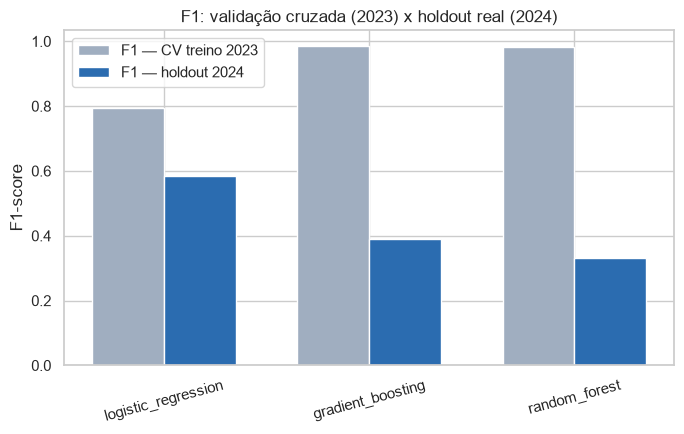

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(df_resultados))
width = 0.35
ax.bar(x - width/2, df_resultados["f1_cv_treino_2023"], width, label="F1 — CV treino 2023", color="#a0aec0")
ax.bar(x + width/2, df_resultados["f1"], width, label="F1 — holdout 2024", color="#2b6cb0")
ax.set_xticks(x)
ax.set_xticklabels(df_resultados["modelo"], rotation=15)
ax.set_ylabel("F1-score")
ax.set_title("F1: validação cruzada (2023) x holdout real (2024)")
ax.legend()
plt.tight_layout()
plt.savefig("../images/overfitting_temporal.png", dpi=150)
plt.show()


## 4. Modelo final selecionado

In [6]:
melhor_nome = df_resultados.iloc[0]["modelo"]
melhor_pipeline = modelos_ajustados[melhor_nome]
print(f"Modelo final (maior ROC-AUC no holdout 2024): {melhor_nome}")
print(json.dumps(df_resultados.iloc[0].to_dict(), indent=2, ensure_ascii=False, default=str))

y_pred_final = melhor_pipeline.predict(X_test)
y_proba_final = melhor_pipeline.predict_proba(X_test)[:, 1]


Modelo final (maior ROC-AUC no holdout 2024): logistic_regression
{
  "accuracy": 0.7173,
  "precision": 0.8081,
  "recall": 0.4569,
  "f1": 0.5838,
  "roc_auc": 0.8191,
  "modelo": "logistic_regression",
  "melhores_parametros": {
    "classifier__C": 1.0
  },
  "f1_cv_treino_2023": 0.7957
}


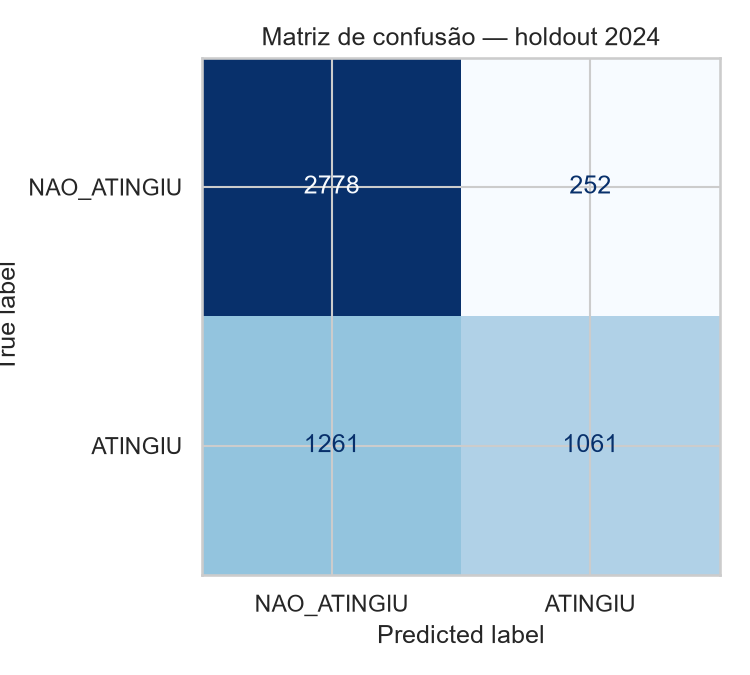

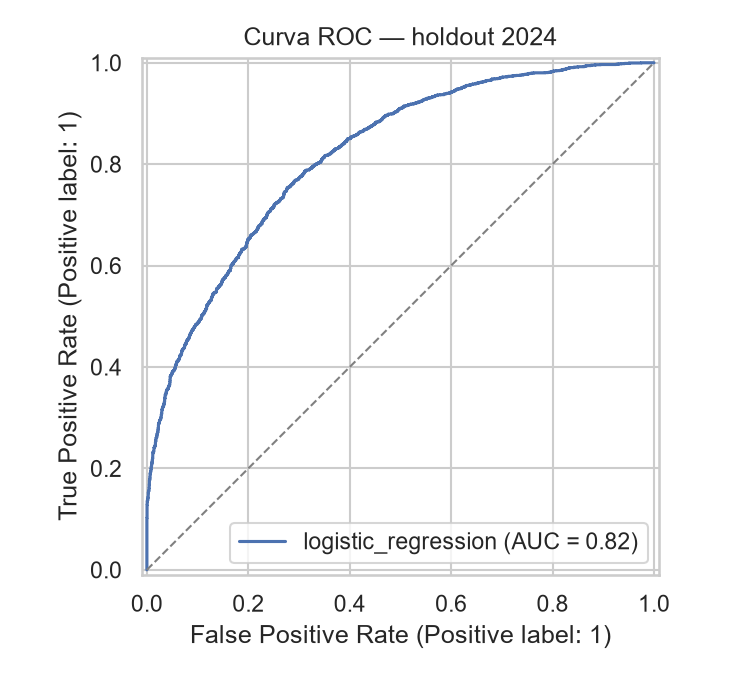

In [7]:
plot_confusion_matrix(y_test, y_pred_final, ROOT / "images" / "matriz_confusao.png")
plot_roc_curve(y_test, y_proba_final, ROOT / "images" / "curva_roc.png", melhor_nome)

from IPython.display import Image, display as ipd_display
ipd_display(Image(filename=str(ROOT / "images" / "matriz_confusao.png")))
ipd_display(Image(filename=str(ROOT / "images" / "curva_roc.png")))


## 5. Interpretabilidade: Feature Importance + SHAP

O objetivo não é apenas ter alta métrica, mas entender **quais fatores mais influenciam** a
predição — pergunta de negócio central do desafio.

Background dataset has 5352 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5352 when initializing the masker.


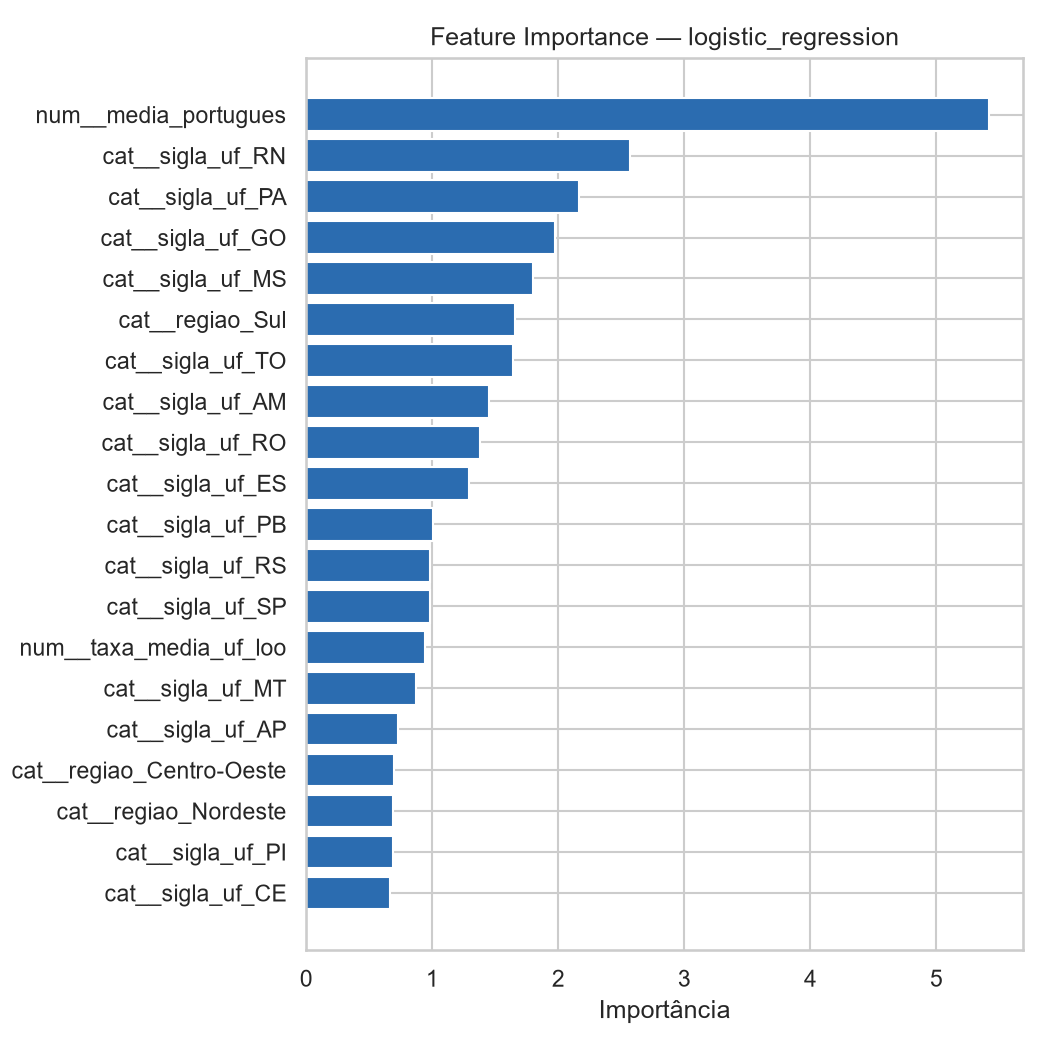

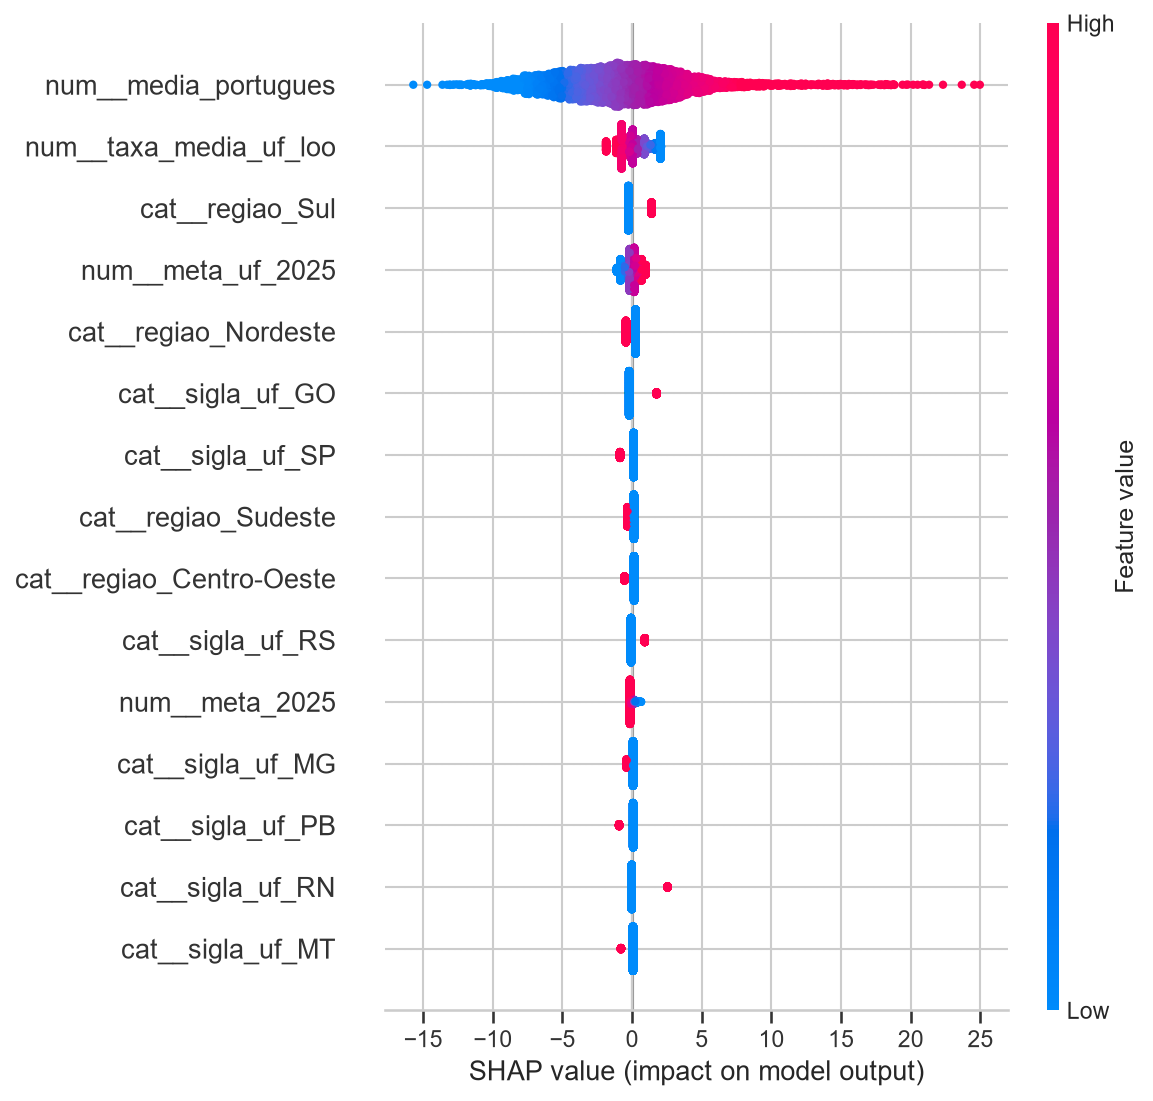

In [8]:
fi = native_feature_importance(melhor_pipeline)
if fi is not None:
    nomes, importancias = fi
    plot_feature_importance(
        nomes, importancias, ROOT / "images" / "feature_importance.png",
        titulo=f"Feature Importance — {melhor_nome}",
    )
    shap_summary(melhor_pipeline, X_test, ROOT / "images" / "shap_summary.png")

    from IPython.display import Image, display as ipd_display
    ipd_display(Image(filename=str(ROOT / "images" / "feature_importance.png")))
    ipd_display(Image(filename=str(ROOT / "images" / "shap_summary.png")))


**Leitura dos resultados:** `media_portugues` (proficiência em Português) domina a importância
— coerente com a correlação de 0,93 observada na EDA, mas sendo uma medida psicométrica distinta
da taxa-alvo, não configura vazamento. Em seguida, indicadores de UF/Região contribuem de forma
secundária, confirmando a heterogeneidade regional identificada na análise exploratória (H2).
O contexto estadual (`taxa_media_uf_loo`, `meta_uf_2025`) tem contribuição menor, mas consistente.


## 6. Aplicação estratégica — respondendo às perguntas de negócio

> Quais municípios apresentam maior risco educacional? Quais regiões possuem padrões semelhantes?


In [9]:
from src.etl.uf_lookup import REGIAO_UF

teste_scored = teste.copy()
teste_scored["prob_atingir_meta"] = melhor_pipeline.predict_proba(X_test)[:, 1]

maior_risco = teste_scored.sort_values("prob_atingir_meta").head(15)
print("15 municípios com MAIOR risco de não atingir a meta de alfabetização em 2024 (menor probabilidade prevista):")
display(maior_risco[["id_municipio", "sigla_uf", "regiao", "media_portugues", "meta_2025", "prob_atingir_meta"]])


15 municípios com MAIOR risco de não atingir a meta de alfabetização em 2024 (menor probabilidade prevista):


,id_municipio,sigla_uf,regiao,media_portugues,meta_2025,prob_atingir_meta
5309,1712702,TO,Norte,685.03,42.72,7.015867e-09
5317,1707702,TO,Norte,689.50,26.30,2.313474e-08
5350,1711951,TO,Norte,694.44,36.33,6.154040e-08
5354,2203354,PI,Nordeste,703.84,47.45,2.279486e-07
5709,2800209,SE,Nordeste,696.85,37.01,3.386801e-07
5459,1709807,TO,Norte,703.57,42.44,4.365150e-07
5318,2919900,BA,Nordeste,695.94,14.66,5.119176e-07
5307,1710706,TO,Norte,704.57,46.88,5.155928e-07
5334,1703008,TO,Norte,704.15,36.07,5.354859e-07
5860,2805109,SE,Nordeste,699.04,29.87,5.954374e-07


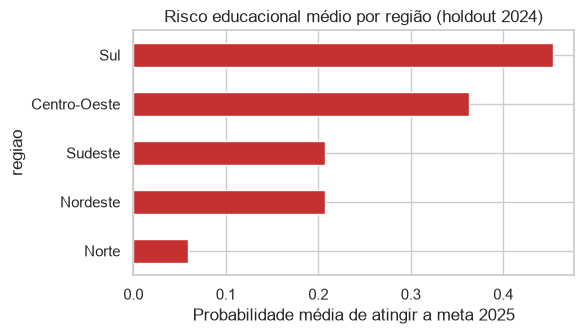

regiao
Norte           0.058595
Nordeste        0.206850
Sudeste         0.207102
Centro-Oeste    0.363104
Sul             0.453775
Name: prob_atingir_meta, dtype: float64

In [10]:
risco_por_regiao = teste_scored.groupby("regiao")["prob_atingir_meta"].mean().sort_values()
ax = risco_por_regiao.plot(kind="barh", figsize=(6, 3.5), color="#c53030")
ax.set_xlabel("Probabilidade média de atingir a meta 2025")
ax.set_title("Risco educacional médio por região (holdout 2024)")
plt.tight_layout()
plt.savefig("../images/risco_por_regiao.png", dpi=150)
plt.show()
risco_por_regiao


## 7. Salvando o modelo final e o resumo do experimento

In [11]:
import joblib

REPORTS_DIR = ROOT / "reports"
REPORTS_DIR.mkdir(exist_ok=True)

joblib.dump(melhor_pipeline, REPORTS_DIR / "modelo_final.joblib")
df_resultados.to_csv(REPORTS_DIR / "comparacao_modelos.csv", index=False)

resumo = {
    "melhor_modelo": melhor_nome,
    "metricas_holdout_2024": df_resultados.iloc[0].to_dict(),
    "matriz_confusao": confusion(y_test, y_pred_final).tolist(),
    "n_treino_2023": int(len(X_train)),
    "n_holdout_2024": int(len(X_test)),
}
with open(REPORTS_DIR / "resumo_treino.json", "w", encoding="utf-8") as f:
    json.dump(resumo, f, ensure_ascii=False, indent=2, default=str)

print("Artefatos salvos em reports/ e images/.")


Artefatos salvos em reports/ e images/.


## 8. Limitações e evoluções futuras

- **Grão de análise**: o alvo é definido no nível *município-ano* (rede municipal), não no nível
  individual do aluno — microdados de alunos não são publicados pelo INEP (sigilo estatístico/LGPD).
- **Janela temporal curta**: apenas 2 anos (2023-2024) de dados públicos consolidados na camada
  Gold da Fase 2, o que limita a validação a um único split temporal (sem múltiplas janelas
  *rolling*). Evolução futura: incorporar mais anos históricos do INEP/ANA quando disponíveis.
- **Enriquecimento externo**: o modelo atual usa apenas features derivadas da própria base
  INEP/PNA. Evoluções futuras podem incorporar IBGE (PIB per capita, IDH municipal), Censo Escolar
  (infraestrutura escolar, formação docente) e Cadastro Único (vulnerabilidade socioeconômica),
  conforme sugerido no enunciado do desafio.
- **Cobertura da visão `comparacao_metas_nacionais`**: observou-se que a rede "total" (código 0)
  do indicador por UF é extremamente esparsa na base de origem (1 registro em toda a série),
  limitando o uso analítico dessa visão específica da camada Gold.
